# EEG Preprocessing - Pre-ICA

Dataset: `ds006780` (ASD EEG, BIDS).
Output: filtered, resampled, bad-channel-interpolated `.fif` files ready for ICA.

Per-file steps: load, set montage, notch, bandpass, resample, detect bad channels, interpolate, save. Bad-channel detection runs after filtering (on clean signal); interpolation happens before saving so the ICA stage sees a uniform channel set.


---
# 1. Setup

## 1.1 Install dependencies (run once)



In [1]:
# !pip install mne mne-bids pandas numpy joblib tqdm
# !pip install pyprep   # optional, for advanced bad-channel detection

## For Deleting Everything

In [2]:

#import shutil
#old_outputs = list(DERIV_ROOT.rglob('*_desc-preproc_eeg.fif'))
#print(f'Will delete {len(old_outputs)} old derivatives (pre-channel-handling-fix)')

#for f in old_outputs:
#   f.unlink()
#print('Cleared.')


# old_blobs = list(gcs_bucket.list_blobs(prefix=GCS_PREFIX))
# print(f'Will delete {len(old_blobs)} old GCS blobs')


#for blob in old_blobs:
#    blob.delete()
# print('GCS cleared.')

## 1.2 Imports

In [3]:
import gc
import json
import traceback
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import mne
from mne_bids import BIDSPath, read_raw_bids, get_entity_vals
from joblib import Parallel, delayed
from tqdm.auto import tqdm


try:
    from pyprep.find_noisy_channels import NoisyChannels
    HAS_PYPREP = True
except ImportError:
    HAS_PYPREP = False

mne.set_log_level('WARNING')
print(f'MNE version:  {mne.__version__}')
print(f'PyPREP available: {HAS_PYPREP}')

MNE version:  1.10.2
PyPREP available: False


---
# 2. Configuration



### Paths

Raw stays on OpenNeuro S3 (read-only, public). Derivatives go to local SSD, then a backup copy to GCS. Writing derivatives to Drive instead of SSD would make every save block on a cloud upload.


In [4]:

DATASET_ID = 'ds006780'
S3_BUCKET  = 'openneuro.org'
S3_PREFIX  = DATASET_ID                   


SCRATCH_ROOT  = Path('/tmp') / 'eeg_scratch' / DATASET_ID
BIDS_ROOT     = SCRATCH_ROOT              
                                         


PROJECT_ROOT  = Path.home() / 'asd_eeg_pipeline'
PIPELINE_NAME = 'mne-preproc-pre-ica'
DERIV_ROOT    = PROJECT_ROOT / 'derivatives' / PIPELINE_NAME
AUDIT_DIR     = PROJECT_ROOT / 'derivatives' / 'audit'
LOG_DIR       = PROJECT_ROOT / 'derivatives' / 'logs'


GCS_BUCKET       = 'asd-eeg-dataset'                       # ← edit this
GCS_PREFIX       = f'derivatives/{DATASET_ID}/{PIPELINE_NAME}'
UPLOAD_TO_GCS    = True
KEEP_LOCAL_DERIV = True  

for d in (SCRATCH_ROOT, DERIV_ROOT, AUDIT_DIR, LOG_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f'☁️  Source:       s3://{S3_BUCKET}/{S3_PREFIX}/')
print(f'📁 Scratch:      {SCRATCH_ROOT}')
print(f'💾 Derivatives:  {DERIV_ROOT}')
print(f'☁️  GCS backup:   gs://{GCS_BUCKET}/{GCS_PREFIX}/')

☁️  Source:       s3://openneuro.org/ds006780/
📁 Scratch:      /tmp/eeg_scratch/ds006780
💾 Derivatives:  /Users/alirezafatemi/asd_eeg_pipeline/derivatives/mne-preproc-pre-ica
☁️  GCS backup:   gs://asd-eeg-dataset/derivatives/ds006780/mne-preproc-pre-ica/


In [5]:
 !pip install boto3 google-cloud-storage


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [6]:

import boto3
from botocore import UNSIGNED
from botocore.config import Config
from google.cloud import storage as gcs_lib


s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))

# GCS client — needs `gcloud auth application-default login` first,
# OR GOOGLE_APPLICATION_CREDENTIALS pointing to a service-account JSON
gcs_client = gcs_lib.Client()
GCS_BUCKET = "asd-eeg-dataset"
gcs_bucket = gcs_client.bucket(GCS_BUCKET)
print(f'✅ S3 client ready (anonymous)')
print(f'✅ GCS bucket:   gs://{GCS_BUCKET}/  (exists: {gcs_bucket.exists()})')

✅ S3 client ready (anonymous)
✅ GCS bucket:   gs://asd-eeg-dataset/  (exists: True)


In [7]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def bootstrap_bids_skeleton(
    local_root: Path,
    extensions=('.json', '.tsv', '.txt', '.md', '.bidsignore'),
    max_workers: int = 32,
    skip_events: bool = False,  
):
    """
    Parallel download of BIDS metadata from S3.
    Resumable: skips files already on disk with matching size.
    """
    paginator = s3.get_paginator('list_objects_v2')


    todo = []
    for page in paginator.paginate(Bucket=S3_BUCKET, Prefix=f'{S3_PREFIX}/'):
        for obj in page.get('Contents', []):
            key, size = obj['Key'], obj['Size']
            if not key.endswith(extensions):
                continue
            if skip_events and key.endswith('_events.tsv'):
                continue
            rel = Path(key).relative_to(S3_PREFIX)
            dst = local_root / rel
            if dst.exists() and dst.stat().st_size == size:
                continue   
            todo.append((key, dst))

    print(f'Listed: {len(todo):,} files to download '
          f'(rest already present or filtered)')
    if not todo:
        print('✅ Nothing to do.')
        return

    # Phase 2
    def _fetch(key, dst):
        dst.parent.mkdir(parents=True, exist_ok=True)
        s3.download_file(S3_BUCKET, key, str(dst))

    failed = []
    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futures = {pool.submit(_fetch, k, d): (k, d) for k, d in todo}
        for fut in tqdm(as_completed(futures), total=len(futures), desc='Skeleton'):
            try:
                fut.result()
            except Exception as e:
                k, d = futures[fut]
                failed.append((k, str(e)))

    print(f'\n✅ Downloaded {len(todo) - len(failed):,} files to {local_root}')
    if failed:
        print(f'⚠️  {len(failed)} failures — first 5:')
        for k, e in failed[:5]:
            print(f'   {k}: {e}')

bootstrap_bids_skeleton(BIDS_ROOT, max_workers=32)

Listed: 10,482 files to download (rest already present or filtered)


Skeleton:   0%|          | 0/10482 [00:00<?, ?it/s]


✅ Downloaded 10,482 files to /tmp/eeg_scratch/ds006780


## 2.2 Per-task processing parameters

Different paradigms → different filters. `motor` keeps higher freqs to preserve beta/gamma.

In [8]:
# Set TASKS = None to process every task in the dataset
TASKS = ['Restingstate', 'FAST', 'IC', 'motor']

TASK_CONFIG = {
    'Restingstate': {'l_freq': 1.0, 'h_freq': 40.0,  'resample_sfreq': 250.0},
    'FAST':         {'l_freq': 1.0, 'h_freq': 40.0,  'resample_sfreq': 250.0},
    'IC':           {'l_freq': 1.0, 'h_freq': 40.0,  'resample_sfreq': 250.0},
    'motor':        {'l_freq': 1.0, 'h_freq': 100.0, 'resample_sfreq': 500.0},
}
DEFAULT_CONFIG = {'l_freq': 1.0, 'h_freq': 40.0, 'resample_sfreq': 250.0}

## 2.3 Bad-channel detection settings

Two methods available:

- **`'lof'`** (default) — MNE's built-in Local Outlier Factor. Fast, no extra deps, decent quality.
- **`'pyprep'`** — PREP-style multi-method detection (deviation + correlation + HF noise + RANSAC). 
  Slower but more thorough. Requires `pip install pyprep`.

In [9]:
BAD_CHANNEL_METHOD = 'lof'      # 'lof' | 'pyprep' | None 
LOF_THRESHOLD       = 1.5       # higher → more permissive (fewer bads)
INTERPOLATE_BADS    = True    


DEFAULT_MONTAGE = 'biosemi64'

In [10]:
# Auxiliary channel handling.
# channels.tsv labels all 8 EXG as 'EMG', but signal inspection shows:
#   EXG1-4: carry signal (~50-100 uV std), not correlated with frontal channels
#           (max r=0.23 with Fp1/Fp2/Fpz). Likely mastoids, not EOG.
#   EXG5-8: flat (~1 uV std), disconnected.
#   Status: BioSemi trigger; events live in events.tsv.
# No EOG channels available, so component labeling in the ICA stage will rely
# on mne-icalabel's topography classifier.

EOG_CHANNELS  = []                                              # none in this dataset
ECG_CHANNELS  = []                                              # none in this dataset
MISC_CHANNELS = ['EXG1', 'EXG2', 'EXG3', 'EXG4']                # active but unknown role
DROP_CHANNELS = ['EXG5', 'EXG6', 'EXG7', 'EXG8', 'Status']      # disconnected + trigger

there is lack of information about Auxiliary channels in this dataset

## 2.4 Execution settings

In [11]:
N_JOBS_INNER = -1       # MNE-internal threading for filter/resample
N_JOBS_OUTER = 1       # parallel files. Keep 1 if reading from Drive (I/O bound).
OVERWRITE    = False   # if True, reprocess files that already have output

---
# 3. Initialize BIDS derivatives dataset
Writes a `dataset_description.json` so the output is a valid BIDS-derivative dataset and has provenance.


In [12]:
def init_bids_derivatives(deriv_root, pipeline_name, source_dataset_id):
    """Write a BIDS-compliant dataset_description.json for the derivative dataset."""
    desc = {
        'Name': f'{source_dataset_id} — {pipeline_name}',
        'BIDSVersion': '1.9.0',
        'DatasetType': 'derivative',
        'GeneratedBy': [{
            'Name': pipeline_name,
            'Version': '0.2.0',
            'Description': (
                'Pre-ICA preprocessing: notch + bandpass + resample + '
                'automated bad channel detection + interpolation.'
            ),
            'CodeURL': 'local notebook',
        }],
        'SourceDatasets': [{'DOI': 'n/a', 'URL': source_dataset_id}],
    }
    out = Path(deriv_root) / 'dataset_description.json'
    out.write_text(json.dumps(desc, indent=2))
    return out

desc_path = init_bids_derivatives(DERIV_ROOT, PIPELINE_NAME, DATASET_ID)
print(f'✅ Wrote {desc_path}')

✅ Wrote /Users/alirezafatemi/asd_eeg_pipeline/derivatives/mne-preproc-pre-ica/dataset_description.json


---
# 4. Core pipeline functions

Each function does one thing. Easy to test, easy to reorder, easy to swap implementations.

## 4.1 Discovery — find BIDS recordings

In [13]:
import re
from mne_bids import BIDSPath

EEG_DATA_EXTS = ('.bdf', '.vhdr', '.edf', '.set')

def discover_recordings_from_s3(tasks=None):
    """Enumerate EEG recordings by listing S3 directly. Returns list[BIDSPath]."""
    paginator = s3.get_paginator('list_objects_v2')
    pat = re.compile(r'(sub|ses|task|run|acq)-([A-Za-z0-9]+)')
    recordings = []

    for page in paginator.paginate(Bucket=S3_BUCKET, Prefix=f'{S3_PREFIX}/'):
        for obj in page.get('Contents', []):
            key = obj['Key']
            if not key.endswith(EEG_DATA_EXTS):
                continue
            name = Path(key).name
            ents = dict(pat.findall(name))
            if tasks and ents.get('task') not in tasks:
                continue
            ext = '.' + name.rsplit('.', 1)[-1]
            bp = BIDSPath(
                subject=ents.get('sub'),
                session=ents.get('ses'),
                task=ents.get('task'),
                run=ents.get('run'),
                acquisition=ents.get('acq'),
                datatype='eeg',
                suffix='eeg',
                extension=ext,
                root=BIDS_ROOT,
                check=False,
            )
            recordings.append(bp)
    return recordings

recordings = discover_recordings_from_s3(tasks=TASKS)
print(f'Found {len(recordings)} recordings across '
      f'{len(set(r.subject for r in recordings))} subjects')

Found 2201 recordings across 139 subjects


## 4.2 Loading

In [14]:
def load_recording(bp, preload=True):
    """Load a BIDS EEG recording. Format-agnostic (BDF, BrainVision, EDF, ...).

    BIDS metadata (channels.tsv bads, events, sidecar info) is preserved automatically.
    """
    raw = read_raw_bids(bp, verbose=False)
    if preload:
        raw.load_data()
    return raw


def get_line_freq(bp, default=60.0):
    """Read PowerLineFrequency from the BIDS sidecar; fall back to `default`."""
    sidecar = bp.copy().update(extension='.json')
    sidecar_path = Path(str(sidecar.fpath))
    if sidecar_path.exists():
        meta = json.loads(sidecar_path.read_text())
        lf = meta.get('PowerLineFrequency')
        if lf is not None and not (isinstance(lf, str) and lf.lower() == 'n/a'):
            try:
                return float(lf)
            except (TypeError, ValueError):
                pass
    return default

## Download and upload  file fif

In [15]:
import shutil
from contextlib import contextmanager
from mne_bids import BIDSPath


from google.cloud.storage.retry import DEFAULT_RETRY

GCS_RETRY   = DEFAULT_RETRY.with_deadline(600).with_delay(initial=2, maximum=30, multiplier=2)
GCS_TIMEOUT = 600                  # seconds per upload attempt
GCS_CHUNK   = 8 * 1024 * 1024      # 8 MB → resumable upload


@contextmanager
def staged_from_s3(bp: BIDSPath):
    """Fetch one recording's data file(s) directly — no S3 listing."""
    sub_seg = f'sub-{bp.subject}'
    ses_seg = f'ses-{bp.session}/' if bp.session else ''
    datatype = bp.datatype or 'eeg'
    s3_dir   = f'{S3_PREFIX}/{sub_seg}/{ses_seg}{datatype}'
    local_dir = BIDS_ROOT / sub_seg / (f'ses-{bp.session}' if bp.session else '') / datatype
    local_dir.mkdir(parents=True, exist_ok=True)

    # What files does this format need?
    base = bp.basename.rsplit('.', 1)[0]   # e.g. sub-10003_task-FAST_run-01_eeg
    if bp.extension == '.vhdr':            # BrainVision = .vhdr + .vmrk + .eeg
        required, optional = [f'{base}.vhdr', f'{base}.vmrk', f'{base}.eeg'], []
    elif bp.extension == '.set':           # EEGLAB = .set + optional .fdt
        required, optional = [f'{base}.set'], [f'{base}.fdt']
    else:                                  # .bdf, .edf = single file
        required, optional = [bp.basename], []

    fetched = []
    for fname in required:
        dst = local_dir / fname
        if not dst.exists():
            s3.download_file(S3_BUCKET, f'{s3_dir}/{fname}', str(dst))
            fetched.append(dst)
    for fname in optional:
        dst = local_dir / fname
        if dst.exists():
            continue
        try:
            s3.download_file(S3_BUCKET, f'{s3_dir}/{fname}', str(dst))
            fetched.append(dst)
        except s3.exceptions.ClientError:
            pass   # optional file genuinely doesn't exist — fine

    try:
        yield bp.copy().update(root=BIDS_ROOT)
    finally:
        for f in fetched:
            try:
                if f.exists() and f.stat().st_size > 1_000_000:
                    f.unlink()
            except OSError:
                pass


def upload_to_gcs(local_path: Path) -> str:
    """Upload a derivative file to GCS with chunked resumable upload + retry."""
    rel = local_path.relative_to(DERIV_ROOT)
    blob_name = f'{GCS_PREFIX}/{rel.as_posix()}'
    blob = gcs_bucket.blob(blob_name, chunk_size=GCS_CHUNK)

    # Skip if already uploaded with matching size
    if blob.exists():
        blob.reload()
        if blob.size == local_path.stat().st_size:
            return f'gs://{GCS_BUCKET}/{blob_name}'

    blob.upload_from_filename(
        str(local_path),
        timeout=GCS_TIMEOUT,
        retry=GCS_RETRY,
    )
    return f'gs://{GCS_BUCKET}/{blob_name}'

## 4.3 Montage

In [16]:
def apply_montage(raw, montage_name=DEFAULT_MONTAGE):

    if raw.get_montage() is not None:
        return False
    montage = mne.channels.make_standard_montage(montage_name)
    raw.set_montage(montage, on_missing='warn', match_case=False)
    return True

## 4.3.5 Auxiliary channel handling:

In [17]:
def set_aux_channel_types(raw,
                          eog_channels=None, ecg_channels=None,
                          emg_channels=None, misc_channels=None,
                          drop_channels=None):
    """Set non-EEG channel types and drop unused channels.

    Filtering, ICA, and bad-channel detection all dispatch on channel type,
    so wrong types lead to wrong behavior.
    """
    type_map = {}
    if eog_channels:
        type_map.update({ch: 'eog'  for ch in eog_channels  if ch in raw.ch_names})
    if ecg_channels:
        type_map.update({ch: 'ecg'  for ch in ecg_channels  if ch in raw.ch_names})
    if emg_channels:
        type_map.update({ch: 'emg'  for ch in emg_channels  if ch in raw.ch_names})
    if misc_channels:
        type_map.update({ch: 'misc' for ch in misc_channels if ch in raw.ch_names})

    n_typed = 0
    if type_map:
        raw.set_channel_types(type_map, verbose=False)
        n_typed = len(type_map)

    n_dropped = 0
    if drop_channels:
        to_drop = [ch for ch in drop_channels if ch in raw.ch_names]
        if to_drop:
            raw.drop_channels(to_drop)
            n_dropped = len(to_drop)

    return {'n_retyped': n_typed, 'n_dropped': n_dropped,
            'retyped': list(type_map.keys()), 'dropped': drop_channels or []}

## 4.4 Filtering — notch, bandpass, resample

In [18]:
def apply_notch(raw, line_freq, n_jobs=N_JOBS_INNER):
    """Remove line noise at the fundamental and all harmonics up to Nyquist."""
    nyquist = raw.info['sfreq'] / 2
    freqs = np.arange(line_freq, nyquist, line_freq)
    if len(freqs):
        raw.notch_filter(freqs=freqs, n_jobs=n_jobs, verbose=False)
    return raw


def apply_bandpass(raw, l_freq, h_freq, n_jobs=N_JOBS_INNER):
    """Bandpass filter. 1 Hz HP is standard pre-ICA — helps ICA convergence."""
    raw.filter(l_freq=l_freq, h_freq=h_freq, n_jobs=n_jobs, verbose=False)
    return raw


def apply_resample(raw, target_sfreq, n_jobs=N_JOBS_INNER):
    """Downsample (only). Skips if data is already at or below target."""
    if target_sfreq and raw.info['sfreq'] > target_sfreq:
        raw.resample(target_sfreq, n_jobs=n_jobs, verbose=False)
    return raw

### Bad channel detection

Both methods augment what's already in `raw.info['bads']` from BIDS rather than replacing it.

- LOF: `mne.preprocessing.find_bad_channels_lof`, detects channels whose spatial pattern is anomalous relative to neighbors.
- PyPREP: multi-method (deviation, correlation, HF noise, RANSAC, dropout). RANSAC is the bottleneck.


In [19]:
from typing import Any


def detect_bad_channels(raw, method='lof', threshold=LOF_THRESHOLD):

    if method is None:
        return []

    existing = set[Any](raw.info['bads'])

    if method == 'lof':
        # Built-in MNE; needs sensor positions
        new_bads = mne.preprocessing.find_bad_channels_lof(
            raw, threshold=threshold, picks='eeg', verbose=False
        )
    elif method == 'pyprep':
        if not HAS_PYPREP:
            raise RuntimeError('PyPREP not installed')
        # PyPREP needs a copy because it modifies in place during RANSAC
        nc = NoisyChannels(raw.copy(), do_detrend=False, random_state=42)
        nc.find_all_bads(ransac=True)
        new_bads = nc.get_bads()
    else:
        raise ValueError(f'Unknown bad-channel method: {method!r}')

    # Merge with any existing bads (e.g. from BIDS channels.tsv)
    truly_new = [ch for ch in new_bads if ch not in existing]
    raw.info['bads'] = sorted(set(raw.info['bads']) | set(new_bads))
    return truly_new


def interpolate_bads_safe(raw):
    """Interpolate bad channels if any are marked. Returns the count interpolated."""
    n_bads = len(raw.info['bads'])
    if n_bads == 0:
        return 0
    raw.interpolate_bads(reset_bads=True, verbose=False)
    # reset_bads=True clears info['bads'] after interpolation, since the channels
    # are now valid again. Keep this if you want to re-detect bads later in the pipeline.
    return n_bads

## 4.6 Saving — BIDS-derivative output

In [20]:
def derivative_path(bp, deriv_root, desc_label, ext='.fif'):
    """
    Output:  <deriv_root>/sub-XXX/eeg/sub-XXX_task-Y_run-ZZ_desc-<label>_eeg.fif
    """
    out_dir = Path(deriv_root) / f'sub-{bp.subject}' / 'eeg'
    out_dir.mkdir(parents=True, exist_ok=True)
    parts = [f'sub-{bp.subject}', f'task-{bp.task}']
    if bp.run is not None:
        parts.append(f'run-{bp.run}')
    parts.extend([f'desc-{desc_label}', 'eeg'])
    return out_dir / ('_'.join(parts) + ext)


def save_derivative(raw, bp, deriv_root, desc_label='preproc'):
    """Save processed Raw to the BIDS-derivative tree as .fif."""
    out = derivative_path(bp, deriv_root, desc_label)
    raw.save(out, overwrite=True, verbose=False)
    return out

## 4.7 Logging utility

In [21]:
def append_log(log_path, record):
    """Append one row to a CSV log, creating with headers if needed.

    Streams to disk so we don't accumulate results in RAM across thousands of files.
    """
    record = {**record, 'timestamp': datetime.now().isoformat(timespec='seconds')}
    df = pd.DataFrame([record])
    header = not Path(log_path).exists()
    df.to_csv(log_path, mode='a', header=header, index=False)

## 4.8 The orchestrator — `process_one`

Glues everything above into the per-file pipeline. **Resumable** (skips finished files), 
**logged** (every file's outcome streamed to CSV), and **memory-safe** (explicit cleanup 
in `finally`).

In [22]:
LOG_FILE = LOG_DIR / '01_preproc_log.csv'
ERROR_LOG = LOG_DIR / '01_preproc_errors.txt'


def process_one(bp, deriv_root=DERIV_ROOT, log_file=LOG_FILE):

    out_path = derivative_path(bp, deriv_root, desc_label='preproc')
    base = {'subject': bp.subject, 'task': bp.task, 'run': bp.run}


    if out_path.exists() and not OVERWRITE:
        result = {**base, 'status': 'skipped', 'out': str(out_path)}
        if log_file is not None: 
            append_log(log_file, result)
        return result

    raw = None
    try:
        cfg = TASK_CONFIG.get(bp.task, DEFAULT_CONFIG)


        raw = load_recording(bp, preload=True)

        n_bads_from_bids = len(raw.info['bads'])

        montage_applied = apply_montage(raw)

        aux_info = set_aux_channel_types(
            raw,
            eog_channels=EOG_CHANNELS,
            ecg_channels=ECG_CHANNELS,
            misc_channels=MISC_CHANNELS,
            drop_channels=DROP_CHANNELS,
        )

        line_freq = get_line_freq(bp)
        apply_notch(raw, line_freq)

        apply_bandpass(raw, l_freq=cfg['l_freq'], h_freq=cfg['h_freq'])


        apply_resample(raw, target_sfreq=cfg['resample_sfreq'])

        new_bads = detect_bad_channels(raw, method=BAD_CHANNEL_METHOD)
        n_bads_total = len(raw.info['bads'])

        n_interpolated = (interpolate_bads_safe(raw)
                          if INTERPOLATE_BADS else 0)

        save_derivative(raw, bp, deriv_root, desc_label='preproc')

        result = {
            **base, 'status': 'ok', 'out': str(out_path),
            'sfreq_out':            raw.info['sfreq'],
            'n_chans':              len(raw.ch_names),
            'n_chans_dropped':      aux_info['n_dropped'],     
            'n_chans_retyped':      aux_info['n_retyped'],    
            'n_bads_from_bids':     n_bads_from_bids,
            'n_bads_detected':      len(new_bads),
            'n_bads_total':         n_bads_total,
            'n_interpolated':       n_interpolated,
            'bads_detected':        ';'.join(new_bads),
            'duration_s':           float(raw.times[-1]),
            'line_freq':            line_freq,
            'montage_applied':      montage_applied,
            'bad_method':           BAD_CHANNEL_METHOD,
        }
    except Exception as e:
        result = {**base, 'status': 'fail', 'error': str(e)}
        with open(ERROR_LOG, 'a') as f:
            f.write(f'\n=== {bp.basename} ===\n{traceback.format_exc()}\n')
    finally:

        if raw is not None:
            del raw
        gc.collect()

    if log_file is not None:
        append_log(log_file, result)
    return result

---
# 5. Stage 0 — Dataset audit (run first)

Reads only JSON sidecars (no signal data) → finishes in minutes for 2700 files.  
Catches mixed sampling rates, mixed line frequencies, missing metadata before you commit.

In [23]:
def audit_one(bp):
    row = {'subject': bp.subject, 'task': bp.task, 'run': bp.run}
    try:
        sidecar_path = Path(str(bp.copy().update(extension='.json').fpath))
        if sidecar_path.exists():
            meta = json.loads(sidecar_path.read_text())
            row['sfreq']         = meta.get('SamplingFrequency')
            row['line_freq']     = meta.get('PowerLineFrequency')
            row['ref']           = meta.get('EEGReference')
            row['n_eeg_chans']   = meta.get('EEGChannelCount')
            row['recording_dur'] = meta.get('RecordingDuration')
        # Format comes from the BIDSPath we built from S3 listing — no disk read needed
        row['format'] = bp.extension or 'unknown'
        row['status'] = 'ok'
    except Exception as e:
        row['status'] = 'fail'
        row['error']  = str(e)
    return row

In [24]:
# Replace the old discover_recordings(BIDS_ROOT, tasks=TASKS) call:
recordings = discover_recordings_from_s3(tasks=TASKS)
print(f'Found {len(recordings)} recordings across '
      f'{len(set(r.subject for r in recordings))} subjects')

audit_rows = [audit_one(bp) for bp in tqdm(recordings, desc='Auditing')]
audit_df = pd.DataFrame(audit_rows)
audit_df.to_csv(AUDIT_DIR / 'audit_summary.csv', index=False)
print(f'\n✅ Audit saved: {AUDIT_DIR / "audit_summary.csv"}')

Found 2201 recordings across 139 subjects


Auditing:   0%|          | 0/2201 [00:00<?, ?it/s]


✅ Audit saved: /Users/alirezafatemi/asd_eeg_pipeline/derivatives/audit/audit_summary.csv


In [25]:
# Inspect what you've got
print('📊 Format distribution:')
print(audit_df['format'].value_counts(), '\n')

print('🎚️  Sampling rates:')
print(audit_df['sfreq'].value_counts(dropna=False), '\n')

print('⚡ Line frequencies:')
print(audit_df['line_freq'].value_counts(dropna=False), '\n')

print('🔌 EEG channel counts:')
print(audit_df['n_eeg_chans'].value_counts(dropna=False), '\n')

print('📋 Per-task counts:')
print(audit_df.groupby('task').size())

📊 Format distribution:
format
.vhdr    1247
.bdf      954
Name: count, dtype: int64 

🎚️  Sampling rates:
sfreq
512.0    2201
Name: count, dtype: int64 

⚡ Line frequencies:
line_freq
60.0    2201
Name: count, dtype: int64 

🔌 EEG channel counts:
n_eeg_chans
64    2201
Name: count, dtype: int64 

📋 Per-task counts:
task
FAST             134
IC               134
Restingstate     686
motor           1247
dtype: int64


---
# 6. Smoke test on one file

**Always run this before launching the full batch.** If your montage is wrong, your
sampling rate is unexpected, or PyPREP errors out — you find out at file 1, not file 1500.

In [26]:
test_bp = recordings[0]
print(f' Testing on: {test_bp.basename}\n')

with staged_from_s3(test_bp) as local_bp:
    test_result = process_one(local_bp, log_file=None)

print(json.dumps(test_result, indent=2, default=str))

 Testing on: sub-10003_task-FAST_run-01_eeg.bdf

{
  "subject": "10003",
  "task": "FAST",
  "run": "01",
  "status": "skipped",
  "out": "/Users/alirezafatemi/asd_eeg_pipeline/derivatives/mne-preproc-pre-ica/sub-10003/eeg/sub-10003_task-FAST_run-01_desc-preproc_eeg.fif"
}


✅ Output:        /Users/alirezafatemi/asd_eeg_pipeline/derivatives/mne-preproc-pre-ica/sub-10003/eeg/sub-10003_task-FAST_run-01_desc-preproc_eeg.fif
   Sampling rate: 250.0 Hz
   Channels:      68  (was 73, expect 68 = 64 EEG + 4 misc)
   Duration:      920.0 s
   Bads in file:  []  (should be empty — they were interpolated)
   File size:     62.6 MB


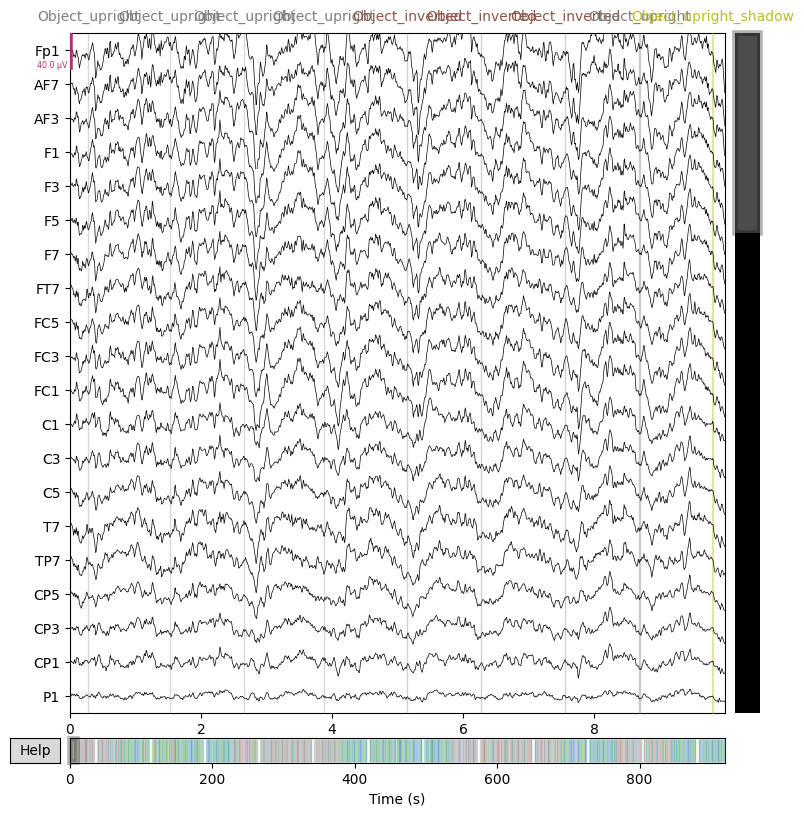

In [27]:
# Verify output 
test_out = derivative_path(test_bp, DERIV_ROOT, 'preproc')
if test_out.exists():
    raw_check = mne.io.read_raw_fif(test_out, preload=False, verbose=False)
    print(f'✅ Output:        {test_out}')
    print(f'   Sampling rate: {raw_check.info["sfreq"]} Hz')
    print(f'   Channels:      {len(raw_check.ch_names)}  (was 73, expect 68 = 64 EEG + 4 misc)')
    
    print(f'   Duration:      {raw_check.times[-1]:.1f} s')
    print(f'   Bads in file:  {raw_check.info["bads"]}  '
          f'(should be empty — they were interpolated)')
    print(f'   File size:     {test_out.stat().st_size / 1e6:.1f} MB')
    raw_check.load_data().plot(duration=10, n_channels=20)   
else:
    print('❌ No output file produced — check', ERROR_LOG)

---
# 7. Run the full batch

Per-file resumable. Safe to interrupt — `OVERWRITE=False` skips finished files on rerun.

In [28]:

print(f'🚀 PASS 1 — Processing {len(recordings)} recordings')
print(f'   Source:        s3://{S3_BUCKET}/{S3_PREFIX}/')
print(f'   Scratch:       {SCRATCH_ROOT}')
print(f'   Local deriv:   {DERIV_ROOT}')
print(f'   Log:           {LOG_FILE}\n')

n_ok, n_skip, n_fail = 0, 0, 0

for bp in tqdm(recordings, desc='Processing'):
    out_path = derivative_path(bp, DERIV_ROOT, 'preproc')

    if not OVERWRITE and out_path.exists():
        n_skip += 1
        continue

    try:
        with staged_from_s3(bp) as local_bp:
            result = process_one(local_bp)
        if result.get('status') == 'ok':
            n_ok += 1
        else:
            n_fail += 1
    except Exception as e:
        n_fail += 1
        print(f'❌ {bp.basename}: {type(e).__name__}: {e}')

print(f'\n✅ Pass 1 complete.')
print(f'   Processed this run: {n_ok}')
print(f'   Already done (skipped): {n_skip}')
print(f'   Failed: {n_fail}')
print(f'   On disk: {sum(1 for _ in DERIV_ROOT.rglob("*_desc-preproc_eeg.fif"))} .fif files')

🚀 PASS 1 — Processing 2201 recordings
   Source:        s3://openneuro.org/ds006780/
   Scratch:       /tmp/eeg_scratch/ds006780
   Local deriv:   /Users/alirezafatemi/asd_eeg_pipeline/derivatives/mne-preproc-pre-ica
   Log:           /Users/alirezafatemi/asd_eeg_pipeline/derivatives/logs/01_preproc_log.csv



Processing:   0%|          | 0/2201 [00:00<?, ?it/s]

/var/folders/83/_ppdmr2x49b7rpvgvxpwsfs40000gn/T/ipykernel_69450/2667447834.py:6: RuntimeWarning: Unable to map the following column(s) to to MNE:
group: TD
handedness: A
completed_ASSR: no
completed_AVSRT: no
completed_Beep-Flash: no
completed_FAST: yes
completed_Illusory_contours: yes
completed_Motor: yes
completed_Resting_state: yes
fsiq: n/a
srs2_total_t: n/a
mabc_total_ss: n/a
cpt_response_style: n/a
ados_css: n/a
medication: n/a
fsiq_dup: n/a
srs2_total_t_dup: n/a
mabc_total_ss_dup: n/a
cpt_response_style_dup: n/a
ados_css_dup: n/a
medication_dup: n/a
  raw = read_raw_bids(bp, verbose=False)
/var/folders/83/_ppdmr2x49b7rpvgvxpwsfs40000gn/T/ipykernel_69450/1792297385.py:22: RuntimeWarning: The unit for channel(s) EXG1, EXG2, EXG3, EXG4 has changed from V to NA.
  raw.set_channel_types(type_map, verbose=False)
/var/folders/83/_ppdmr2x49b7rpvgvxpwsfs40000gn/T/ipykernel_69450/2667447834.py:6: RuntimeWarning: Unable to map the following column(s) to to MNE:
group: TD
handedness: A
com

KeyboardInterrupt: 

In [ ]:
import pandas as pd
df = pd.read_csv('~/asd_eeg_pipeline/derivatives/logs/01_preproc_log.csv')


fails = df[df['status'] == 'fail']
print(f'Total failures: {len(fails)}')
print()

# cluster by error message
print('Error patterns:')
print(fails['error'].value_counts())
print()

# cluster by subject/task — same subject failing all tasks? same task across subjects?
print('Failures by subject:')
print(fails['subject'].value_counts().head(20))
print()
print('Failures by task:')
print(fails['task'].value_counts())

ParserError: Error tokenizing data. C error: Expected 6 fields in line 3, saw 17


In [ ]:

# PASS 2 — Upload all derivatives to GCS

from concurrent.futures import ThreadPoolExecutor, as_completed

UPLOAD_WORKERS = 8   # bump to 6-8 on fast wired connection, drop to 2 on weak wifi

if not UPLOAD_TO_GCS:
    print('⏭️  UPLOAD_TO_GCS is False — skipping pass 2.')
else:
    to_upload = sorted(DERIV_ROOT.rglob('*_desc-preproc_eeg.fif'))
    total_bytes = sum(p.stat().st_size for p in to_upload)
    print(f'☁️  PASS 2 — Uploading {len(to_upload)} files '
          f'({total_bytes / 1e9:.1f} GB total) to gs://{GCS_BUCKET}/{GCS_PREFIX}/')
    print(f'   Workers:       {UPLOAD_WORKERS}')
    print(f'   Log:           {LOG_DIR / "gcs_uploads.tsv"}\n')

    gcs_log = LOG_DIR / 'gcs_uploads.tsv'
    n_uploaded, n_failed = 0, 0
    failures = []

    def _upload(path):
        return path, upload_to_gcs(path)

    with ThreadPoolExecutor(max_workers=UPLOAD_WORKERS) as pool:
        futures = {pool.submit(_upload, p): p for p in to_upload}
        for fut in tqdm(as_completed(futures), total=len(futures), desc='Uploading'):
            path = futures[fut]
            try:
                _, gcs_uri = fut.result()
                with open(gcs_log, 'a') as f:
                    f.write(f'{path.name}\t{gcs_uri}\n')
                n_uploaded += 1
                if not KEEP_LOCAL_DERIV:
                    path.unlink()
            except Exception as e:
                n_failed += 1
                failures.append((path.name, f'{type(e).__name__}: {e}'))    
        
    print(f'\n✅ Pass 2 complete.')
    print(f'   Uploaded: {n_uploaded}')
    print(f'   Failed:   {n_failed}')
    if failures:
        print(f'\n⚠️  Failures (first 10):')
        for name, err in failures[:10]:
            print(f'   {name}  →  {err}')
        print('\n   Just rerun this cell — successful uploads are skipped, only failures retry.')

☁️  PASS 2 — Uploading 2171 files (49.8 GB total) to gs://asd-eeg-dataset/derivatives/ds006780/mne-preproc-pre-ica/
   Workers:       8
   Log:           /Users/alirezafatemi/asd_eeg_pipeline/derivatives/logs/gcs_uploads.tsv



Uploading:   0%|          | 0/2171 [00:00<?, ?it/s]


✅ Pass 2 complete.
   Uploaded: 2171
   Failed:   0


---
# 8. Inspect the run

Read the log fresh from disk — we don't keep results in memory.

In [ ]:
log_df = pd.read_csv(LOG_FILE, on_bad_lines='skip')

print('Columns:')
print(log_df.columns.tolist(), '\n')

print('Status counts:')
print(log_df['status'].value_counts(), '\n')

fails = log_df[log_df['status'] == 'fail']

if len(fails):

    print(f'⚠️  {len(fails)} failures — see {ERROR_LOG}')

    wanted_cols = ['subject', 'task', 'run', 'error']

    existing_cols = [c for c in wanted_cols if c in fails.columns]

    print(fails[existing_cols].head(20))

else:
    print('🎉 No failures.')

Columns:
['subject', 'task', 'run', 'status', 'out', 'timestamp'] 

Status counts:
status
fail       70
skipped     1
Name: count, dtype: int64 

⚠️  70 failures — see /Users/alirezafatemi/asd_eeg_pipeline/derivatives/logs/01_preproc_errors.txt
    subject   task  run
1     10003  motor    1
2     10003  motor    2
3     10003  motor    3
4     10003  motor    4
5     10003  motor    5
6     10003  motor    6
7     10003  motor    7
8     10003  motor    8
9     10003  motor    9
10    10003  motor   10
11    10708   FAST    1
12    10708     IC    1
13    10931  motor    1
14    10931  motor    2
15    10931  motor    3
16    10931  motor    4
17    10931  motor    5
18    10931  motor    6
19    10931  motor    7
20    10931  motor    8


In [ ]:
from collections import Counter
import re

error_groups = []

with open(ERROR_LOG, 'r') as f:
    text = f.read()

chunks = text.split("=== ")

for c in chunks:

    if 'Traceback' not in c:
        continue

    if 'vmrk' in c:
        error_groups.append('missing_vmrk')

    elif 'participants.tsv' in c or 'is not in list' in c:
        error_groups.append('participants_mismatch')

    elif 'BioSemi64' in c:
        error_groups.append('montage_typo')

    elif 'File does not exist' in c:
        error_groups.append('missing_file')

    else:
        error_groups.append('other')

print(Counter(error_groups))

Counter({'participants_mismatch': 60, 'missing_vmrk': 10, 'montage_typo': 4, 'missing_file': 1})


In [ ]:
participants = pd.read_csv(
    BIDS_ROOT / "participants.tsv",
    sep="\t"
)

participants_ids = set(
    participants["participant_id"].astype(str)
)

recording_ids = set()

for p in BIDS_ROOT.rglob("sub-*"):

    if p.is_dir():
        recording_ids.add(p.name)

missing = sorted(recording_ids - participants_ids)

print("Missing in participants.tsv:")
print(missing)

print()
print("Count:", len(missing))

Missing in participants.tsv:
['sub-10708', 'sub-10931', 'sub-10950']

Count: 3


In [ ]:

ok = log_df[log_df['status'] == 'ok']
if len(ok):
    print('Bad channels detected per file (LOF/PyPREP):')
    print(ok['n_bads_detected'].describe(), '\n')

    print('Channels interpolated per file:')
    print(ok['n_interpolated'].describe(), '\n')


    threshold = 10
    suspicious = ok[ok['n_bads_total'] > threshold]
    if len(suspicious):
        print(f'⚠️  {len(suspicious)} files had >{threshold} bad channels — '
              f'inspect these manually:')
        print(suspicious[['subject','task','run','n_bads_total','bads_detected']].head(20))

In [ ]:

if len(ok):
    print('Output sampling rates:')
    print(ok['sfreq_out'].value_counts(), '\n')
    print('Channel counts:')
    print(ok['n_chans'].value_counts(), '\n')
    print(f'Total signal duration processed: {ok["duration_s"].sum()/3600:.1f} hours')

---
# 9. Output layout & what's next

```
~/asd_eeg_pipeline/derivatives/
├── mne-preproc-pre-ica/                       ← BIDS derivative dataset
│   ├── dataset_description.json
│   └── sub-XXXXX/eeg/
│       └── sub-XXXXX_task-X_run-XX_desc-preproc_eeg.fif
├── audit/
│   └── audit_summary.csv
└── logs/
    ├── 01_preproc_log.csv                     ← per-file results
    └── 01_preproc_errors.txt                  ← full tracebacks
```

